In [1]:
from rabtracks import *
sns.set_context("paper")

In [2]:
data = {b: xr.open_dataset("../RABTracks/RABTracks_"+b+".nc") for b in BASINS}

/tmp/ipykernel_2596/2144106322.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  data = {b: xr.open_dataset("../RABTracks/RABTracks_"+b+".nc") for b in BASINS}
/tmp/ipykernel_2596/2144106322.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  data = {b: xr.open_dataset("../RABTracks/RABTracks_"+b+".nc") for b in BASINS}


In [3]:
for b in data:
    data[b]["lat_pres"] = data[b].lat_pres.where(np.abs(data[b].lat_pres) <= 90)
    data[b]["lon_pres"] = data[b].lon_pres.where(np.abs(data[b].lat_pres) <= 360)
    
    use_pres = data[b].source.str.startswith("TRACK")        # dims: (source,)
    use_pres_2d = use_pres.broadcast_like(data[b]["lat"])        # dims: (record, source)
    
    data[b]["lat_mixed"] = xr.where(
        use_pres_2d,  # use pres_lat only for chosen sources AND where it’s not NaN
        data[b]["lat_pres"],
        data[b]["lat"]
    )

    data[b]["lon_mixed"] = xr.where(
        use_pres_2d,  # use pres_lon only for chosen sources AND where it’s not NaN
        data[b]["lon_pres"],
        data[b]["lon"]
    )
    data[b]["lon_mixed"] = xr.where(
        data[b]["lon_mixed"] > 180,  # use pres_lon only for chosen sources AND where it’s not NaN
        data[b]["lon_mixed"] - 360,
        data[b]["lon_mixed"]
    )

In [4]:
# Distance between IBTrACS and sources
def haversine4(a,b,c,d):
    return haversine((a,b),(c,d))
haversine_vec = np.vectorize(haversine4)

In [5]:
# Compute dist2ib
for b in BASINS:
    data[b]["dist2ib_psl"] = xr.apply_ufunc(haversine_vec, 
            data[b].sel(source = "IBTrACS").lat_mixed, 
            data[b].sel(source = "IBTrACS").lon_mixed, 
           data[b].lat_mixed, data[b].lon_mixed)
    data[b]["dist2ib"] = xr.apply_ufunc(haversine_vec, 
            data[b].sel(source = "IBTrACS").lat, 
            data[b].sel(source = "IBTrACS").lon, 
           data[b].lat, data[b].lon)

/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2625: RuntimeWarning: invalid value encountered in haversine4 (vectorized)
  outputs = ufunc(*args, out=...)


<Axes: xlabel='basin', ylabel='source'>

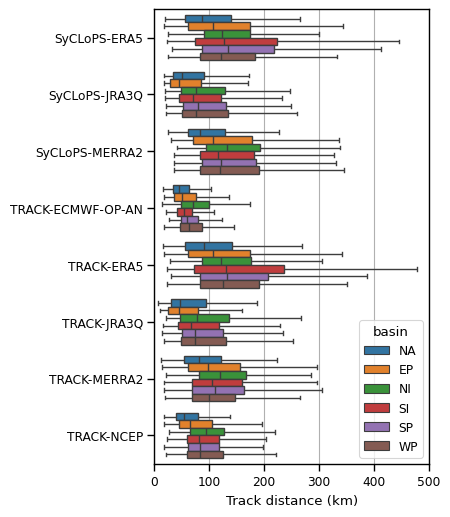

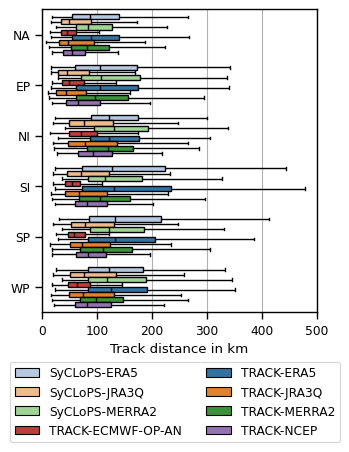

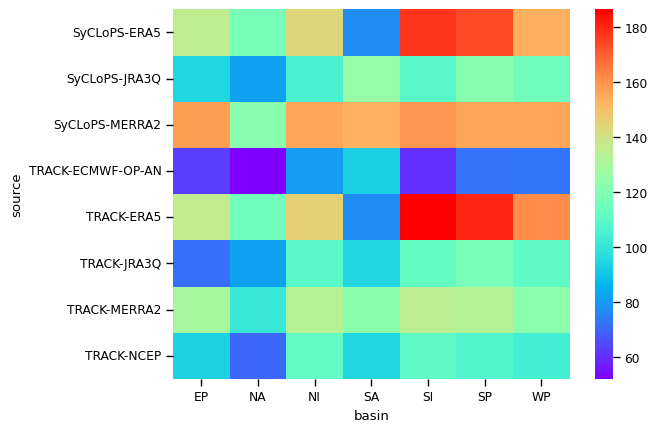

In [6]:
sns.set_palette("tab10")

df = pd.DataFrame()
for b in BASINS:
    eib = data[b]
    BINS = np.arange(0, 501, 20)

    # Track by track
    #fig, axs = plt.subplots()
    for ds in eib.source.values:
        if ds != "IBTrACS":
            D = eib.sel(source = ds)["dist2ib_psl"].groupby(eib.track_id).mean()
            D_series = pd.Series(D.where(D.notnull(), drop = True).values).rename("D_track")
            D_df = pd.DataFrame(D_series).assign(source = ds, basin = b)
            df = pd.concat([df, D_df])
df
fig = plt.figure(figsize = cm2inch([9,15]))
ax = sns.boxplot(data = df[df.basin != "SA"], 
            x = "D_track", y = "source", 
            hue = "basin", #palette = PALETTE, 
           showfliers = False)
ax.set_xlim(0,500)
ax.set_ylabel("")
ax.set_xlabel("Track distance (km)")
ax.grid(axis = 'x')

plt.savefig("matching_distance.png", bbox_inches = "tight")
plt.savefig("matching_distance.pdf", bbox_inches = "tight")

fig = plt.figure(figsize = cm2inch([9,10]))
ax = sns.boxplot(data = df[df.basin != "SA"], 
            x = "D_track", y = "basin", 
            hue = "source", palette = PALETTE, 
           showfliers = False)
ax.set_xlim(0,500)
ax.set_ylabel("")
ax.set_xlabel("Track distance in km")
ax.grid(axis = 'x')

ax.get_legend().remove()
fig.legend(ncol = 2, loc = "outside upper center", 
           bbox_to_anchor = (0.5, 0.0), frameon = True)

mean = df.groupby(["source", "basin"]).D_track.mean().reset_index().pivot_table(columns = "basin", index = "source").D_track
plt.figure()
sns.heatmap(mean, cmap = "rainbow")

In [7]:
M = mean.loc[mean.index.str.endswith("ERA5") | 
    mean.index.str.endswith("JRA3Q") | mean.index.str.endswith("MERRA2")]
M = M.reset_index()
M["tracker"] = M.source.str.split('-', expand = True)[0]
M["RA"] = M.source.str.split('-', expand = True)[1]
#M = M.set_index("RA").drop(columns = ["source"])
#M = M[M.tracker == "SyCLoPS"].drop(columns = ["tracker"]) - M[M.tracker == "TRACK"].drop(columns = ["tracker"])

In [8]:
M.groupby("RA").mean()

TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
sns.heatmap(M, cmap = "RdBu_r", vmin = -60, vmax = 60)

In [ ]:
plt.pcolormesh(M.iloc[:3].values - M.iloc[3:].values, cmap = "RdBu", vmax = 60, vmin = -60)
plt.colorbar()

In [ ]:
sns.set_palette("tab10")

df = pd.DataFrame()
for b in BASINS:
    eib = data[b]
    BINS = np.arange(0, 501, 20)

    # Track by track
    #fig, axs = plt.subplots()
    for ds in eib.source.values:
        if ds != "IBTrACS":
            D = eib.sel(source = ds)["dist2ib"].groupby(eib.track_id).mean()
            D_series = pd.Series(D.where(D.notnull(), drop = True).values).rename("D_track")
            D_df = pd.DataFrame(D_series).assign(source = ds, basin = b)
            df = pd.concat([df, D_df])
df
fig = plt.figure(figsize = cm2inch([9,15]))
ax = sns.boxplot(data = df[df.basin != "SA"], 
            x = "D_track", y = "source", 
            hue = "basin", #palette = PALETTE, 
           showfliers = False)
ax.set_xlim(0,500)
ax.set_ylabel("")
ax.set_xlabel("Track distance (km)")
ax.grid(axis = 'x')

plt.savefig("matching_distance.png", bbox_inches = "tight")
plt.savefig("matching_distance.pdf", bbox_inches = "tight")

fig = plt.figure(figsize = cm2inch([9,10]))
ax = sns.boxplot(data = df[df.basin != "SA"], 
            x = "D_track", y = "basin", 
            hue = "source", palette = PALETTE, 
           showfliers = False)
ax.set_xlim(0,500)
ax.set_ylabel("")
ax.set_xlabel("Track distance in km")
ax.grid(axis = 'x')

ax.get_legend().remove()
fig.legend(ncol = 2, loc = "outside upper center", 
           bbox_to_anchor = (0.5, 0.0), frameon = True)

mean = df.groupby(["source", "basin"]).D_track.mean().reset_index().pivot_table(columns = "basin", index = "source").D_track
plt.figure()
sns.heatmap(mean, cmap = "rainbow")

In [ ]:
df.groupby("source").D_track.mean()